# N-BEATS Forecaster

This notebook shows how to use `NBEATSForecaster` for online time-series forecasting. The model receives one target value at a time, predicts from the recent target history, and then updates itself with `learn_one`.

## Generate a streaming time series

The example uses a small synthetic signal with a daily-like seasonal pattern, a mild trend, and noise. This keeps the notebook self-contained while still showing a nonlinear forecasting problem.

In [8]:
import math
import random

import matplotlib.pyplot as plt
from river import metrics

from deep_river.forecasting import LinearForecaster, NBEATSForecaster

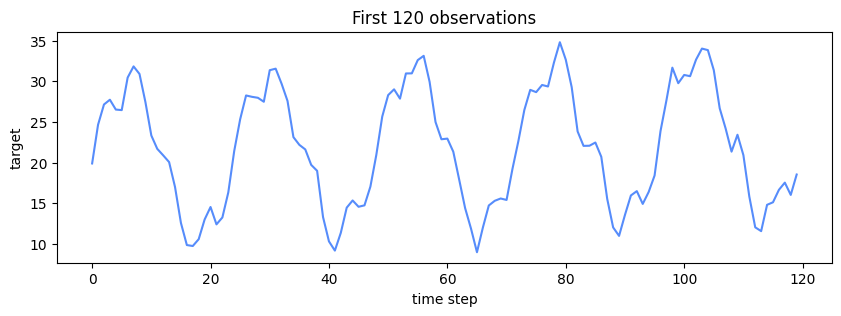

In [9]:
def make_stream(n=284, seed=42):
    rng = random.Random(seed)
    for t in range(n):
        seasonal = 10 * math.sin(2 * math.pi * t / 24)
        short_cycle = 2.5 * math.sin(2 * math.pi * t / 6)
        trend = 0.03 * t
        noise = rng.gauss(0, 0.8)
        yield 20 + trend + seasonal + short_cycle + noise


values = list(make_stream())
observed_values = values[:260]
holdout_values = values[260:]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(values[:120])
ax.set_title("First 120 observations")
ax.set_xlabel("time step")
ax.set_ylabel("target")
plt.show()

## Online one-step-ahead evaluation

At each time step, the model first forecasts the next value from its current target window. After the true value arrives, the metric is updated and the model learns from that value. This is the usual prequential evaluation pattern for streaming models.

In [10]:
def evaluate_one_step(model, values, warmup=24):
    metric = metrics.MAE()
    forecasts = []

    for t, y in enumerate(values):
        y_pred = model.forecast(horizon=1)[0]
        forecasts.append(y_pred)

        if t >= warmup:
            metric.update(y, y_pred)

        model.learn_one(y)

    return metric.get(), forecasts


nbeats = NBEATSForecaster(
    window_size=24,
    n_width=32,
    n_layers=2,
    n_blocks=3,
    optimizer_fn="adam",
    lr=1e-3,
    seed=42,
)
linear = LinearForecaster(
    window_size=24,
    optimizer_fn="adam",
    lr=1e-3,
    seed=42,
)

nbeats_mae, nbeats_forecasts = evaluate_one_step(nbeats, observed_values)
linear_mae, linear_forecasts = evaluate_one_step(linear, observed_values)

print(f"N-BEATS MAE: {nbeats_mae:.3f}")
print(f"Linear MAE:  {linear_mae:.3f}")

N-BEATS MAE: 4.668
Linear MAE:  5.098


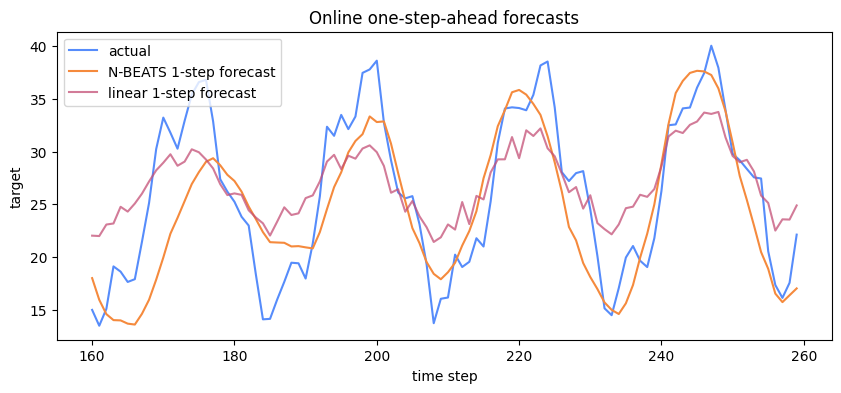

In [11]:
start = 160
x_axis = range(start, len(observed_values))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_axis, observed_values[start:], label="actual")
ax.plot(x_axis, nbeats_forecasts[start:], label="N-BEATS 1-step forecast")
ax.plot(x_axis, linear_forecasts[start:], label="linear 1-step forecast", alpha=0.75)
ax.set_title("Online one-step-ahead forecasts")
ax.set_xlabel("time step")
ax.set_ylabel("target")
ax.legend()
plt.show()

## Multi-step forecasting

`forecast(horizon=k)` rolls the model forward autoregressively: each predicted value is fed back into a copied history window to produce the next prediction. The model is not updated during this call.

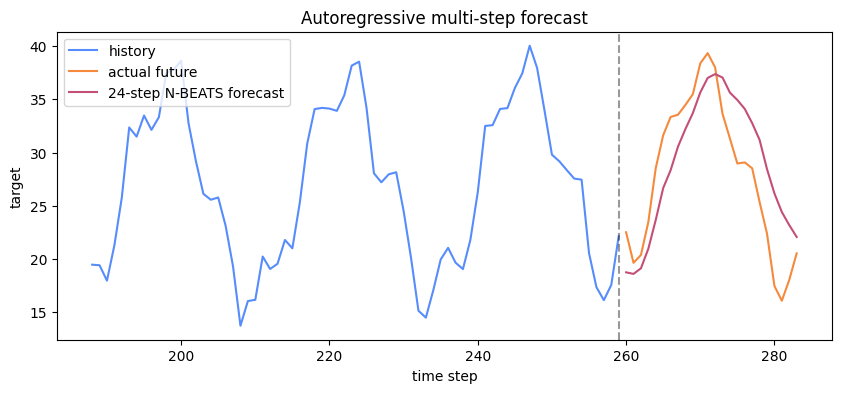

In [12]:
horizon = len(holdout_values)
future_forecast = nbeats.forecast(horizon=horizon)
future_axis = range(len(observed_values), len(observed_values) + horizon)
history_axis = range(len(observed_values) - 72, len(observed_values))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_axis, observed_values[-72:], label="history")
ax.plot(future_axis, holdout_values, label="actual future")
ax.plot(future_axis, future_forecast, label="24-step N-BEATS forecast")
ax.axvline(len(observed_values) - 1, color="black", linestyle="--", alpha=0.4)
ax.set_title("Autoregressive multi-step forecast")
ax.set_xlabel("time step")
ax.set_ylabel("target")
ax.legend()
plt.show()

## Inspect the N-BEATS blocks

The compact N-BEATS module is a stack of MLP blocks. Earlier blocks compute a `backcast` that updates the residual input for the next block, and every block contributes a one-step `forecast`. The final block only contributes a forecast because there is no later block that would consume a final residual.

In [ ]:
for i, block in enumerate(nbeats.module.blocks):
    print(f"block {i}: has_backcast={block.backcast is not None}")